4.2 - Treinamento de RNN  
Aluno: Stevan Maciel Ribeiro de Souza  
Matrícula: 2022003307

In [1]:
pip install ucimlrepo

#Importar Bibliotecas Necessárias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from ucimlrepo import fetch_ucirepo

#Carregar o Dataset

In [3]:
appliances_energy_prediction = fetch_ucirepo(id=374)
X = appliances_energy_prediction.data.features
y = appliances_energy_prediction.data.targets

#Pré-processamento dos Dados

In [4]:
# Usar apenas a coluna de consumo de energia ('Appliances') de y
data = y.copy()
data.index = X['date']
data.index = data.index.str.replace(r'(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})', r'\1 \2', regex=True)
data.index = pd.to_datetime(data.index)
data = data.sort_index()

# Normalização dos Dados
scaler = MinMaxScaler()
data['Appliances'] = scaler.fit_transform(data[['Appliances']])

#Divisão dos Dados em Treinamento e Teste

In [5]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

#Preparar os Dados para a Rede Neural Recorrente (RNN)

In [6]:
def create_sequences(dataset, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(dataset) - seq_length):
        X_seq.append(dataset[i:i+seq_length])
        y_seq.append(dataset[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24  #Utilizar as ultimas 24 horas para previsão
X_train, y_train = create_sequences(train['Appliances'].values, seq_length)
X_test, y_test = create_sequences(test['Appliances'].values, seq_length)

# Ajustar formato para LSTM [amostras, passos de tempo, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

#Construção do Modelo e Treinamento

In [7]:
model = Sequential()
model.add(LSTM(50, input_shape=(seq_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0068 - val_loss: 0.0034
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0037 - val_loss: 0.0030
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0041 - val_loss: 0.0030
Epoch 9/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0039 - val_loss: 0.0030
Epoch 10/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0038 - val_loss: 0.0030


#Avaliação e Previsão do Modelo

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
RMSE: 58.55
MAE: 25.71


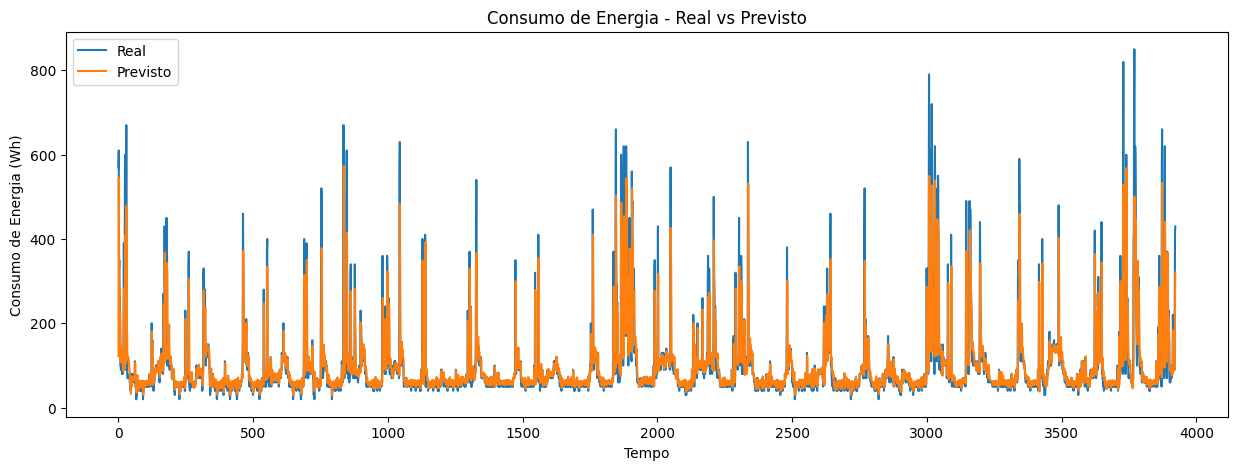

In [8]:
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

plt.figure(figsize=(15,5))
plt.plot(y_test_inv, label='Real')
plt.plot(y_pred_inv, label='Previsto')
plt.title('Consumo de Energia - Real vs Previsto')
plt.xlabel('Tempo')
plt.ylabel('Consumo de Energia (Wh)')
plt.legend()
plt.show()